# Estudo de caso SEMAD-GO — queimadas em Goiás (safra de seca 2024)

Consultoria de dados para a Secretaria de Estado de Meio Ambiente e Desenvolvimento Sustentável de Goiás.

**Objetivo:** calcular medidas de tendência central e de dispersão da variável `focos_calor` e responder ao questionário avaliativo (10 questões).

**Recorte:** 31 municípios reais × 5 meses (junho a outubro de 2024) = 155 registros, em duas regiões:

- Norte/Nordeste (Vão do Paranã / Chapada dos Veadeiros)
- Sul/Sudoeste (fronteira agrícola)

**Convenção deste notebook:** variância e desvio padrão **populacionais** (`ddof=0`), conforme o enunciado. O CV é apresentado em percentual: \(CV = \sigma / \mu \times 100\%\).


## 0. Bibliotecas, leitura e função de medidas


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.float_format", "{:.4f}".format)

ROOT = Path.cwd()
if not (ROOT / "data" / "focos_queimada_goias.csv").exists():
    ROOT = ROOT.parent

df = pd.read_csv(ROOT / "data" / "focos_queimada_goias.csv")
print("Linhas:", len(df))
print("Municípios:", df["municipio"].nunique())
print("Meses:", sorted(df["mes"].unique().tolist()))
print(df["regiao"].value_counts())
df.head()


Linhas: 155
Municípios: 31
Meses: [6, 7, 8, 9, 10]
regiao
Norte/Nordeste    105
Sul/Sudoeste       50
Name: count, dtype: int64


,municipio,regiao,mes,mes_nome,ano,focos_calor,precipitacao_mm,temp_max_media_c
0,Alto Paraiso de Goias,Norte/Nordeste,6,junho,2024,11,5.9000,29.7000
1,Alto Paraiso de Goias,Norte/Nordeste,7,julho,2024,25,3.8000,31.0000
2,Alto Paraiso de Goias,Norte/Nordeste,8,agosto,2024,48,9.7000,32.5000
3,Alto Paraiso de Goias,Norte/Nordeste,9,setembro,2024,65,57.2000,33.9000
4,Alto Paraiso de Goias,Norte/Nordeste,10,outubro,2024,25,158.7000,32.5000


In [2]:
def medidas(serie: pd.Series) -> pd.Series:
    """Medidas pedidas no enunciado para uma série de focos_calor."""
    media = serie.mean()
    dp = serie.std(ddof=0)
    vc = serie.value_counts()
    moda_freq = int(vc.iloc[0])
    modas = vc[vc == moda_freq].index.tolist()
    return pd.Series(
        {
            "n": int(serie.count()),
            "media": media,
            "mediana": serie.median(),
            "moda": modas[0] if len(modas) == 1 else f"multimodal {modas}",
            "freq_moda": moda_freq,
            "minimo": serie.min(),
            "maximo": serie.max(),
            "amplitude": serie.max() - serie.min(),
            "variancia_pop": serie.var(ddof=0),
            "desvio_padrao_pop": dp,
            "cv_percent": (dp / media) * 100,
        }
    )


norte = df.loc[df["regiao"] == "Norte/Nordeste", "focos_calor"]
sul = df.loc[df["regiao"] == "Sul/Sudoeste", "focos_calor"]
completo = df["focos_calor"]

resumo = pd.DataFrame(
    {
        "Norte/Nordeste": medidas(norte),
        "Sul/Sudoeste": medidas(sul),
        "Dataset completo": medidas(completo),
    }
)
resumo


,Norte/Nordeste,Sul/Sudoeste,Dataset completo
n,105.0000,50,155
media,32.0190,43.6600,35.7742
mediana,22.0000,32.0000,25.0000
moda,11.0000,"multimodal [6, 16, 19, 31, 7, 12, 26, 39, 13, ...","multimodal [11, 13]"
freq_moda,6.0000,2,6
minimo,3.0000,5,3
maximo,172.0000,184,184
amplitude,169.0000,179,181
variancia_pop,1070.7806,1510.1844,1242.1361
desvio_padrao_pop,32.7228,38.8611,35.2440


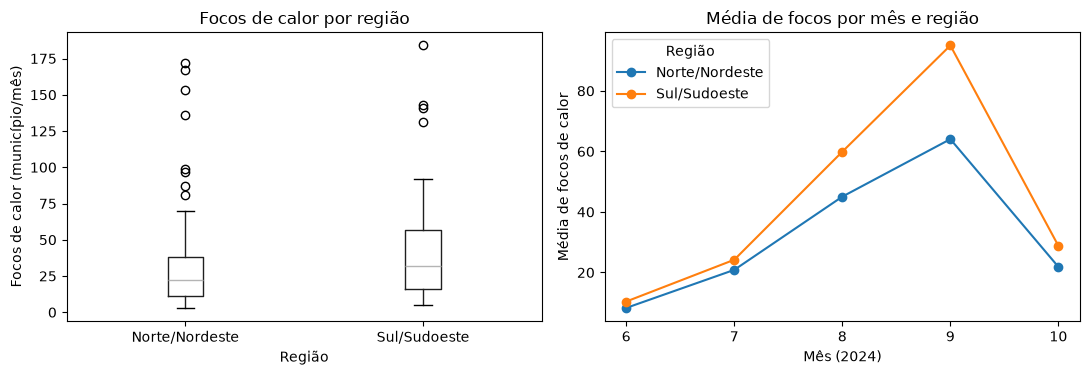

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

df.boxplot(column="focos_calor", by="regiao", ax=axes[0], grid=False)
axes[0].set_title("Focos de calor por região")
axes[0].set_xlabel("Região")
axes[0].set_ylabel("Focos de calor (município/mês)")
axes[0].get_figure().suptitle("")

media_mes = (
    df.groupby(["mes", "regiao"], as_index=False)["focos_calor"]
    .mean()
    .pivot(index="mes", columns="regiao", values="focos_calor")
)
media_mes.plot(ax=axes[1], marker="o")
axes[1].set_title("Média de focos por mês e região")
axes[1].set_xlabel("Mês (2024)")
axes[1].set_ylabel("Média de focos de calor")
axes[1].set_xticks([6, 7, 8, 9, 10])
axes[1].legend(title="Região")

fig.tight_layout()
plt.show()


## Questão 1 — média por região

Calcule a média de `focos_calor` por município/mês para cada uma das duas regiões. Qual região apresenta a maior média?


In [4]:
media_norte = norte.mean()
media_sul = sul.mean()

print(f"Norte/Nordeste: soma={norte.sum()}  n={norte.count()}  media={norte.sum() / norte.count():.4f}")
print(f"Sul/Sudoeste:   soma={sul.sum()}  n={sul.count()}  media={sul.sum() / sul.count():.4f}")
print("Maior média:", "Sul/Sudoeste" if media_sul > media_norte else "Norte/Nordeste")


Norte/Nordeste: soma=3362  n=105  media=32.0190
Sul/Sudoeste:   soma=2183  n=50  media=43.6600
Maior média: Sul/Sudoeste


**Resposta.** Norte/Nordeste = **32,02** focos (3362 / 105). Sul/Sudoeste = **43,66** focos (2183 / 50). A região **Sul/Sudoeste** tem a maior média.


## Questão 2 — mediana versus média (simetria)

Calcule a mediana de `focos_calor` para cada região e compare com a média da Questão 1. A diferença sugere distribuição simétrica ou assimétrica? Justifique.


In [5]:
print("Norte/Nordeste  media={:.4f}  mediana={:.1f}  diferenca={:.4f}".format(
    norte.mean(), norte.median(), norte.mean() - norte.median()
))
print("Sul/Sudoeste    media={:.4f}  mediana={:.1f}  diferenca={:.4f}".format(
    sul.mean(), sul.median(), sul.mean() - sul.median()
))


Norte/Nordeste  media=32.0190  mediana=22.0  diferenca=10.0190
Sul/Sudoeste    media=43.6600  mediana=32.0  diferenca=11.6600


**Resposta.** Mediana Norte/Nordeste = **22**; Sul/Sudoeste = **32**. Nas duas regiões a média é maior que a mediana (diferenças de +10,02 e +11,66). Isso indica **assimetria à direita**: poucos município-mês com focos muito altos puxam a média, enquanto o centro da distribuição (mediana) permanece mais baixo.


## Questão 3 — moda

Identifique a moda de `focos_calor` em cada região. O valor modal é um bom resumo dos dados? Justifique com a frequência de repetição.


In [6]:
print("Norte/Nordeste — 8 valores mais frequentes:")
print(norte.value_counts().head(8))
print()
print("Sul/Sudoeste — 12 valores mais frequentes:")
print(sul.value_counts().head(12))


Norte/Nordeste — 8 valores mais frequentes:
focos_calor
11    6
22    4
13    4
21    4
5     4
4     4
33    4
25    3
Name: count, dtype: int64

Sul/Sudoeste — 12 valores mais frequentes:
focos_calor
6     2
16    2
19    2
31    2
7     2
12    2
26    2
39    2
13    2
92    2
44    2
14    1
Name: count, dtype: int64


**Resposta.** Norte/Nordeste: moda = **11** (frequência 6 em 105, cerca de 5,7%). Sul/Sudoeste: **não há moda única** — 11 valores empatam com frequência 2. A moda **não é um bom resumo**: no Norte ela é rara e fica bem abaixo da média e da mediana; no Sul a repetição máxima é só 2 observações, então o valor modal quase não representa o conjunto.


## Questão 4 — amplitude

Calcule a amplitude (máximo - mínimo) em cada região. O que ela revela — e o que ela NÃO revela — sobre a variabilidade?


In [7]:
print("Norte/Nordeste: max={}  min={}  amplitude={}".format(
    norte.max(), norte.min(), norte.max() - norte.min()
))
print("Sul/Sudoeste:   max={}  min={}  amplitude={}".format(
    sul.max(), sul.min(), sul.max() - sul.min()
))


Norte/Nordeste: max=172  min=3  amplitude=169
Sul/Sudoeste:   max=184  min=5  amplitude=179


**Resposta.** Amplitude Norte/Nordeste = **169** (172 - 3). Sul/Sudoeste = **179** (184 - 5). A amplitude mostra só a distância entre os extremos. Ela **não** diz se a maioria dos pontos está perto da média, se a dispersão é geral ou se um único outlier explica o intervalo. Por isso não substitui variância, desvio padrão nem CV.


## Questão 5 — variância populacional

\(\sigma^2 = \dfrac{\sum (x_i - \mu)^2}{N}\)


In [8]:
print("Norte/Nordeste var_pop =", norte.var(ddof=0))
print("Sul/Sudoeste   var_pop =", sul.var(ddof=0))
print()
print("Conferencia pela definição (Norte/Nordeste):")
mu = norte.mean()
print(((norte - mu) ** 2).sum() / len(norte))


Norte/Nordeste var_pop = 1070.780589569161
Sul/Sudoeste   var_pop = 1510.1844

Conferencia pela definição (Norte/Nordeste):
1070.780589569161


**Resposta.** Variância populacional Norte/Nordeste = **1070,78**. Sul/Sudoeste = **1510,18**. Usamos `ddof=0` porque o enunciado pede variância populacional (dividir por N, não por N-1).


## Questão 6 — desvio padrão populacional

\(\sigma = \sqrt{\sigma^2}\). Interprete o valor em relação à respectiva média.


In [9]:
dp_norte = norte.std(ddof=0)
dp_sul = sul.std(ddof=0)
print("Norte/Nordeste dp={:.4f}  media={:.4f}  dp/media={:.4f}".format(
    dp_norte, norte.mean(), dp_norte / norte.mean()
))
print("Sul/Sudoeste   dp={:.4f}  media={:.4f}  dp/media={:.4f}".format(
    dp_sul, sul.mean(), dp_sul / sul.mean()
))


Norte/Nordeste dp=32.7228  media=32.0190  dp/media=1.0220
Sul/Sudoeste   dp=38.8611  media=43.6600  dp/media=0.8901


**Resposta.** Desvio padrão Norte/Nordeste = **32,72** focos: os valores se afastam da média 32,02 por cerca de 32,7 focos (dispersão típica da mesma ordem da média). Sul/Sudoeste = **38,86** focos frente à média 43,66. Em termos absolutos o Sul varia mais; nas duas regiões o desvio padrão é alto em relação à média.


## Questão 7 — coeficiente de variação

\(CV = \dfrac{\sigma}{\mu} \times 100\%\)

Como as médias são diferentes, o que é mais adequado para comparar a variabilidade relativa: o desvio padrão bruto ou o CV? Qual região é relativamente mais homogênea?


In [10]:
cv_norte = norte.std(ddof=0) / norte.mean() * 100
cv_sul = sul.std(ddof=0) / sul.mean() * 100
print(f"CV Norte/Nordeste = {cv_norte:.4f}%")
print(f"CV Sul/Sudoeste   = {cv_sul:.4f}%")
print("Mais homogênea (menor CV):", "Sul/Sudoeste" if cv_sul < cv_norte else "Norte/Nordeste")


CV Norte/Nordeste = 102.1979%
CV Sul/Sudoeste   = 89.0085%
Mais homogênea (menor CV): Sul/Sudoeste


**Resposta.** CV Norte/Nordeste = **102,20%**. CV Sul/Sudoeste = **89,01%**. O **CV** é a medida adequada para comparar variabilidade relativa, porque as médias são diferentes; o desvio padrão bruto não equaliza a escala. Pelo CV, o **Sul/Sudoeste é relativamente mais homogêneo**. No Norte a dispersão supera a própria média (CV > 100%).


## Questão 8 — setembro (mês de pico) versus dataset completo

Filtre `mes = 9` e calcule média, mediana e desvio padrão de todos os municípios juntos. Compare com junho–outubro. O que isso indica sobre a sazonalidade na variabilidade?


In [11]:
setembro = df.loc[df["mes"] == 9, "focos_calor"]

comparacao = pd.DataFrame(
    {
        "Dataset completo (jun–out)": [
            completo.mean(),
            completo.median(),
            completo.std(ddof=0),
        ],
        "Somente setembro": [
            setembro.mean(),
            setembro.median(),
            setembro.std(ddof=0),
        ],
    },
    index=["media", "mediana", "desvio_padrao_pop"],
)
comparacao


,Dataset completo (jun–out),Somente setembro
media,35.7742,74.0323
mediana,25.0000,58.0000
desvio_padrao_pop,35.2440,47.3753


**Resposta.** Completo: média **35,77**, mediana **25,00**, desvio padrão **35,24**. Setembro: média **74,03**, mediana **58,00**, desvio padrão **47,38**. O mês de pico mais do que dobra o nível médio e aumenta a dispersão absoluta. A sazonalidade da seca concentra risco em setembro: o patamar sobe em todo o estado e os municípios se afastam mais uns dos outros em número de focos. Usar só a média do semestre esconde o pico operacional.


## Questão 9 — outlier e robustez da média

Localize o registro com o maior `focos_calor`. Recalcule média e mediana da região dele sem esse ponto. Qual medida de tendência central é mais sensível a extremos? Por quê?


In [12]:
idx = df["focos_calor"].idxmax()
outlier = df.loc[idx]
print(outlier[["municipio", "regiao", "mes_nome", "focos_calor"]].to_string())

regiao_out = outlier["regiao"]
com = df.loc[df["regiao"] == regiao_out, "focos_calor"]
sem = df.loc[(df["regiao"] == regiao_out) & (df.index != idx), "focos_calor"]

print()
print(f"Região {regiao_out}")
print(f"n com outlier={com.count()}  n sem={sem.count()}")
print(f"media    com={com.mean():.4f}  sem={sem.mean():.4f}  delta={com.mean() - sem.mean():.4f}")
print(f"mediana  com={com.median():.4f}  sem={sem.median():.4f}  delta={com.median() - sem.median():.4f}")


municipio          Mineiros
regiao         Sul/Sudoeste
mes_nome           setembro
focos_calor             184

Região Sul/Sudoeste
n com outlier=50  n sem=49
media    com=43.6600  sem=40.7959  delta=2.8641
mediana  com=32.0000  sem=31.0000  delta=1.0000


**Resposta.** Outlier: **Mineiros, setembro/2024, 184 focos** (Sul/Sudoeste). Sem esse registro, a média da região cai de **43,66** para **40,80** (-2,86) e a mediana de **32** para **31** (-1). A **média** é mais sensível a extremos porque todos os valores entram na soma; a mediana só depende da posição central da série ordenada.


## Questão 10 — parecer técnico (prioridade de fiscalização)

Com base em todas as medidas, compare nível médio e variabilidade das duas regiões e indique a prioridade de fiscalização — considerando magnitude e dispersão, não apenas os totais.


In [13]:
totais = df.groupby("regiao")["focos_calor"].agg(["sum", "mean", "median", "count"])
totais["cv_percent"] = [
    norte.std(ddof=0) / norte.mean() * 100,
    sul.std(ddof=0) / sul.mean() * 100,
]
totais


,sum,mean,median,count,cv_percent
regiao,,,,,
Norte/Nordeste,3362,32.0190,22.0000,105,102.1979
Sul/Sudoeste,2183,43.6600,32.0000,50,89.0085


**Parecer.** O Sul/Sudoeste tem maior magnitude média de focos por município/mês (43,66 contra 32,02) e maior dispersão absoluta (desvio padrão 38,86; amplitude 179). O Norte/Nordeste é relativamente mais instável: CV de 102,20%, média puxada por picos (Cavalcante, Niquelândia, Monte Alegre de Goiás) e mediana de apenas 22 focos. O total de focos é maior no Norte só porque essa região reúne 21 dos 31 municípios da amostra, não porque o risco por localidade seja mais alto. Recomenda-se priorizar a fiscalização contínua na fronteira agrícola do Sul/Sudoeste, onde o patamar elevado é mais homogêneo (CV 89,01%), e complementar com operações pontuais nos municípios-pico do Norte/Nordeste. O planejamento deve usar média, mediana e CV juntos: a média sozinha superestima o município típico, e o total sozinho distorce a comparação entre regiões de tamanhos diferentes.
